In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
data = pd.read_csv("/content/riceClassification.csv")
data.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data.drop(['id'], axis = 1, inplace = True)
data.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [13]:
X = np.array(data.iloc[:, :-1])
y = np.array(data.iloc[:, -1])
X.shape, y.shape

((18185, 10), (18185,))

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.3)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12729, 10), (5456, 10), (12729,), (5456,))

In [15]:
X_test , X_val , y_test , y_val = train_test_split(X_test, y_test, test_size = 0.5)
X_test.shape, X_val.shape, y_test.shape, y_val.shape

((2728, 10), (2728, 10), (2728,), (2728,))

In [16]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [17]:
class dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype = torch.float32)
    self.y = torch.tensor(y, dtype = torch.float32)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

  def __len__(self):
    return len(self.X)

In [18]:
train_data = dataset(X_train, y_train)
test_data = dataset(X_test, y_test)
val_data = dataset(X_val, y_val)


batch_size = 32
train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_data, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = True)

In [25]:
import torch.nn as nn

HIDDEN_UNITS = 20

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(10, HIDDEN_UNITS),
            nn.ReLU(),
            nn.Linear(HIDDEN_UNITS, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the model
model = Model().to(device)
summary(model, (X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1]                       --
├─Sequential: 1-1                        [1]                       --
│    └─Linear: 2-1                       [20]                      220
│    └─ReLU: 2-2                         [20]                      --
│    └─Linear: 2-3                       [1]                       21
│    └─Sigmoid: 2-4                      [1]                       --
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [27]:
criterion = nn.BCELoss()
# Using Adam optimizer, learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_loss_total = []
train_acc_total = []
val_loss_total = []
val_acc_total = []

epochs = 15

for epoch in range(epochs):
  model.train()

  train_loss = 0
  train_acc = 0

  for data, label in train_loader:
    data = data.to(device)
    label = label.to(device)
    prediction = model(data)
    label = label.unsqueeze(1)
    loss = criterion(prediction, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_acc += (prediction.round() == label).sum().item() / len(label)


  # --- VALIDATION PHASE ---
  model.eval()
  val_loss = 0
  val_acc = 0
  with torch.no_grad():
    for data, label in val_loader:
      data = data.to(device)
      label = label.to(device)
      prediction = model(data)
      label = label.unsqueeze(1)
      loss = criterion(prediction, label)
      val_loss += loss.item()
      val_acc += (prediction.round() == label).sum().item() / len(label)


  avg_train_loss = train_loss / len(train_loader)
  avg_train_acc = train_acc / len(train_loader)
  avg_val_loss = val_loss / len(val_loader)
  avg_val_acc = val_acc / len(val_loader)

  train_loss_total.append(avg_train_loss)
  train_acc_total.append(avg_train_acc)
  val_loss_total.append(avg_val_loss)
  val_acc_total.append(avg_val_acc)

  # Print progress
  print(f"Epoch {epoch+1}/{epochs}| "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")



Epoch 1/15| Train Loss: 0.0442 | Train Acc: 0.9856 | Val Loss: 0.0354 | Val Acc: 0.9887
Epoch 2/15| Train Loss: 0.0436 | Train Acc: 0.9859 | Val Loss: 0.0416 | Val Acc: 0.9891
Epoch 3/15| Train Loss: 0.0433 | Train Acc: 0.9860 | Val Loss: 0.0350 | Val Acc: 0.9887
Epoch 4/15| Train Loss: 0.0427 | Train Acc: 0.9862 | Val Loss: 0.0353 | Val Acc: 0.9902
Epoch 5/15| Train Loss: 0.0427 | Train Acc: 0.9862 | Val Loss: 0.0343 | Val Acc: 0.9895
Epoch 6/15| Train Loss: 0.0428 | Train Acc: 0.9859 | Val Loss: 0.0341 | Val Acc: 0.9898
Epoch 7/15| Train Loss: 0.0422 | Train Acc: 0.9865 | Val Loss: 0.0348 | Val Acc: 0.9891
Epoch 8/15| Train Loss: 0.0418 | Train Acc: 0.9868 | Val Loss: 0.0338 | Val Acc: 0.9895
Epoch 9/15| Train Loss: 0.0417 | Train Acc: 0.9860 | Val Loss: 0.0346 | Val Acc: 0.9891
Epoch 10/15| Train Loss: 0.0418 | Train Acc: 0.9867 | Val Loss: 0.0342 | Val Acc: 0.9891
Epoch 11/15| Train Loss: 0.0410 | Train Acc: 0.9866 | Val Loss: 0.0338 | Val Acc: 0.9891
Epoch 12/15| Train Loss: 0.040

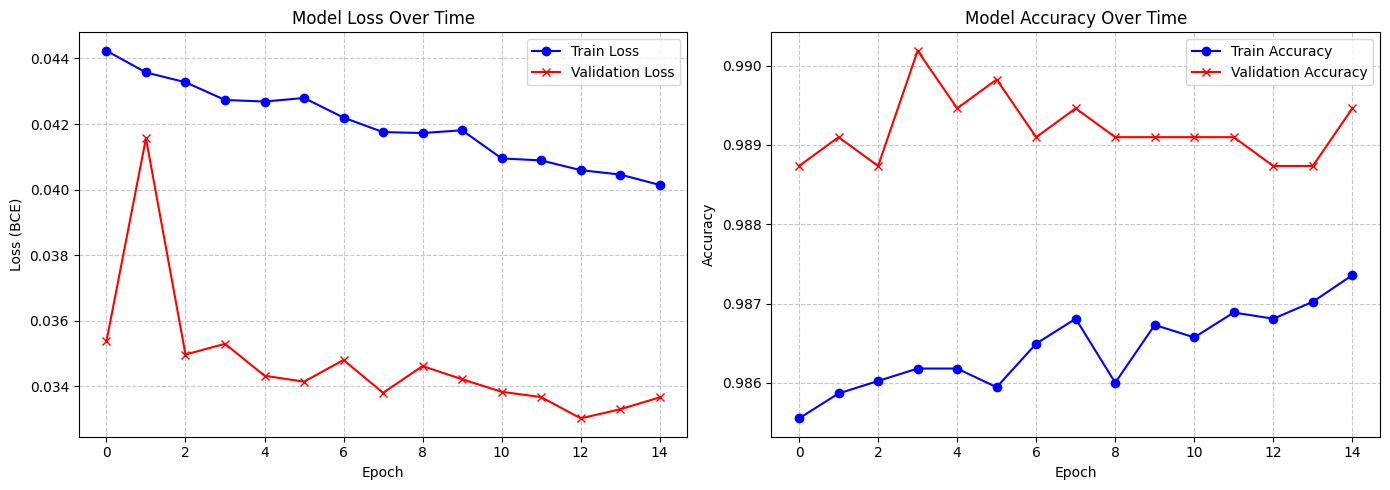

In [28]:
import matplotlib.pyplot as plt

# Create a figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss ---
ax1.plot(train_loss_total, label='Train Loss', color='blue', marker='o')
ax1.plot(val_loss_total, label='Validation Loss', color='red', marker='x')
ax1.set_title('Model Loss Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (BCE)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Accuracy ---
ax2.plot(train_acc_total, label='Train Accuracy', color='blue', marker='o')
ax2.plot(val_acc_total, label='Validation Accuracy', color='red', marker='x')
ax2.set_title('Model Accuracy Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping and display the graph
plt.tight_layout()
plt.show()

In [29]:
# 1. Put the model in evaluation mode
model.eval()

test_loss = 0
test_acc = 0

# 2. Turn off gradients to save memory and compute
with torch.no_grad():
    for data, label in test_loader:
        # Move data to the same device as the model (GPU/CPU)
        data = data.to(device)
        label = label.to(device).unsqueeze(1)

        # Make predictions
        prediction = model(data)

        # Calculate loss
        loss = criterion(prediction, label)

        # Accumulate metrics
        test_loss += loss.item()
        test_acc += (prediction.round() == label).sum().item() / len(label)

# 3. Calculate final averages
final_test_loss = test_loss / len(test_loader)
final_test_acc = test_acc / len(test_loader)

print("--- FINAL TEST RESULTS ---")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.4f}")

--- FINAL TEST RESULTS ---
Test Loss: 0.0267
Test Accuracy: 0.9916
